<a href="https://colab.research.google.com/github/Bpatnaik470/Bpatnaik470/blob/main/Creating_Cohorts_of_Songs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd

file_path = '/content/adultcensusincome.csv'
df = pd.read_csv(file_path)
display(df.head())

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,Female,0,3900,40,United-States,<=50K


In [22]:
import numpy as np

# Identify columns with '?' and replace them with NaN
for col in df.columns:
    if (df[col] == '?').any():
        print(f"Column '{col}' contains '?' values.")
df.replace('?', np.nan, inplace=True)

# Check for null values after replacing '?'
print("\nMissing values after replacing '?':")
display(df.isnull().sum())

# Handle missing values (e.g., drop rows with any missing values if their count is not too high)
# Let's see the percentage of missing values first to decide on the handling strategy
missing_percentage = df.isnull().sum() / len(df) * 100
display(missing_percentage[missing_percentage > 0])

# For this dataset, let's drop rows with missing values, as they are relatively few
df_cleaned = df.dropna().copy()
print(f"\nOriginal dataset size: {len(df)}")
print(f"Cleaned dataset size after dropping rows with missing values: {len(df_cleaned)}")


Column 'workclass' contains '?' values.
Column 'occupation' contains '?' values.
Column 'native.country' contains '?' values.

Missing values after replacing '?':


,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
sex,0
capital.gain,0


,0
workclass,5.638647
occupation,5.660146
native.country,1.790486



Original dataset size: 32561
Cleaned dataset size after dropping rows with missing values: 30162


In [23]:
# Check the distribution of the target variable 'income'
income_distribution = df_cleaned['income'].value_counts(normalize=True) * 100
print("\nDistribution of 'income' variable:")
display(income_distribution)

# Identify if the dataset is balanced
if income_distribution.min() < 20: # A common heuristic for imbalanced datasets
    print("\nThe dataset is imbalanced as one class ('<=50K') significantly outweighs the other.")
else:
    print("\nThe dataset appears to be relatively balanced.")



Distribution of 'income' variable:


,proportion
income,
<=50K,75.107751
>50K,24.892249



The dataset appears to be relatively balanced.


/tmp/ipykernel_698/3609779794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df_cleaned, palette='viridis')


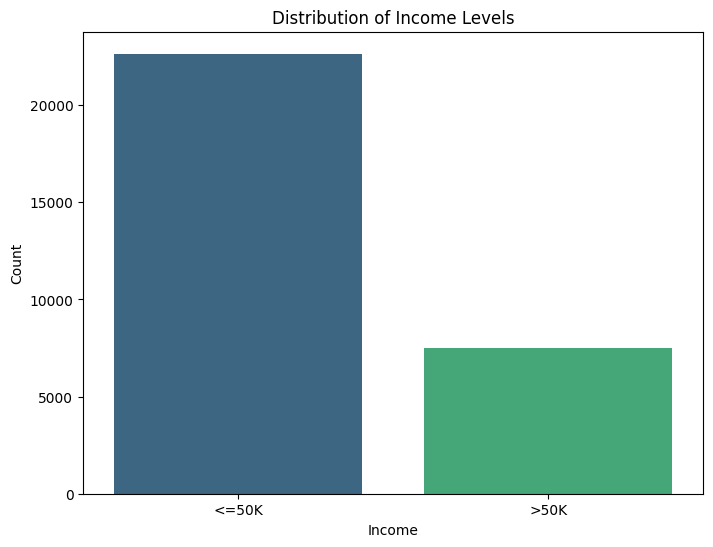

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='income', data=df_cleaned, palette='viridis')
plt.title('Distribution of Income Levels')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_698/1552249482.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_cleaned['age'], bins=30, kde=True, palette='viridis')


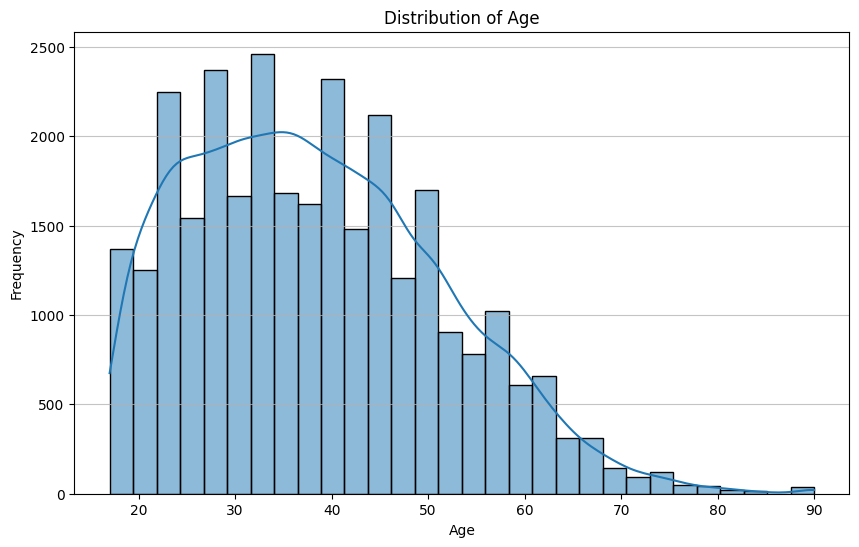

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['age'], bins=30, kde=True, palette='viridis')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

/tmp/ipykernel_698/397875528.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='education.num', data=df_cleaned, palette='viridis')


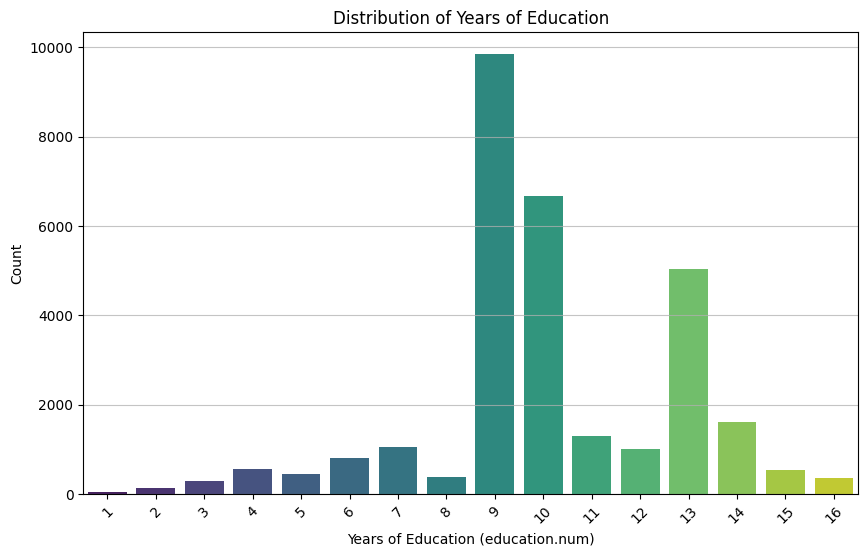

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='education.num', data=df_cleaned, palette='viridis')
plt.title('Distribution of Years of Education')
plt.xlabel('Years of Education (education.num)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.show()

/tmp/ipykernel_698/1526066593.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='education', data=df_cleaned, palette='viridis', order = df_cleaned['education'].value_counts().index)


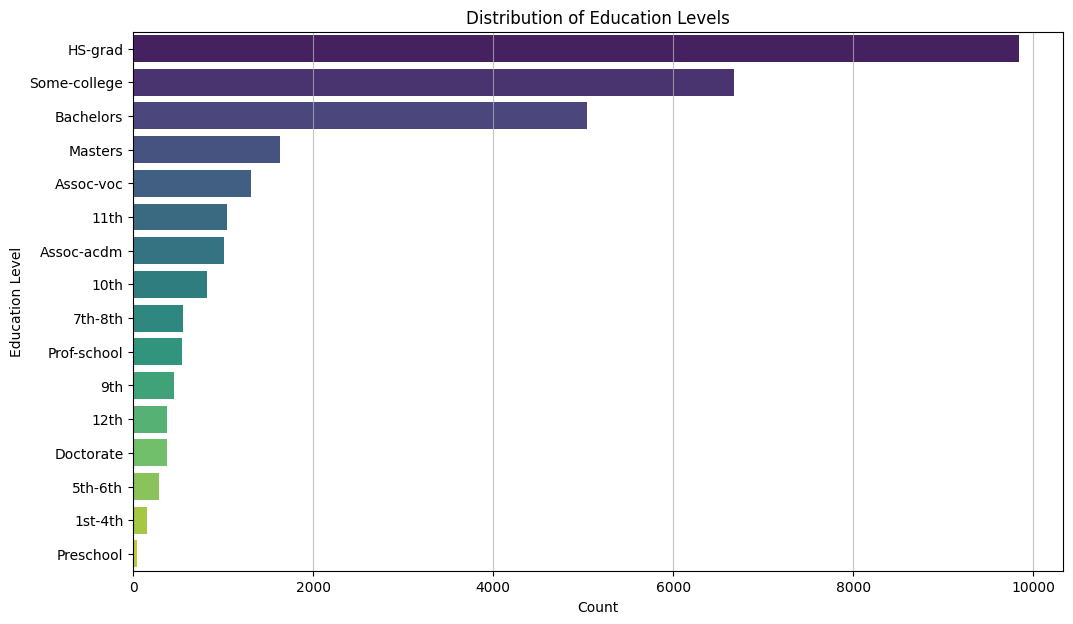

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(y='education', data=df_cleaned, palette='viridis', order = df_cleaned['education'].value_counts().index)
plt.title('Distribution of Education Levels')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.grid(axis='x', alpha=0.75)
plt.show()

/tmp/ipykernel_698/397875528.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='education.num', data=df_cleaned, palette='viridis')


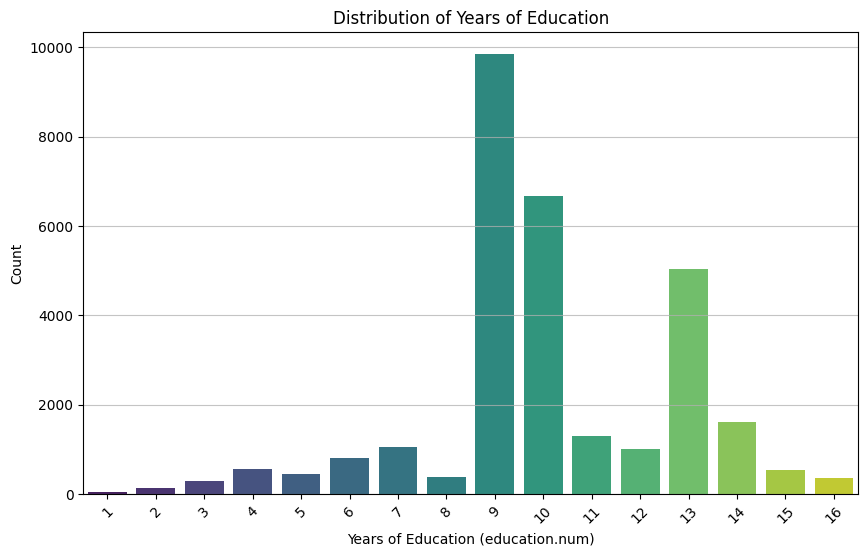

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='education.num', data=df_cleaned, palette='viridis')
plt.title('Distribution of Years of Education')
plt.xlabel('Years of Education (education.num)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.show()

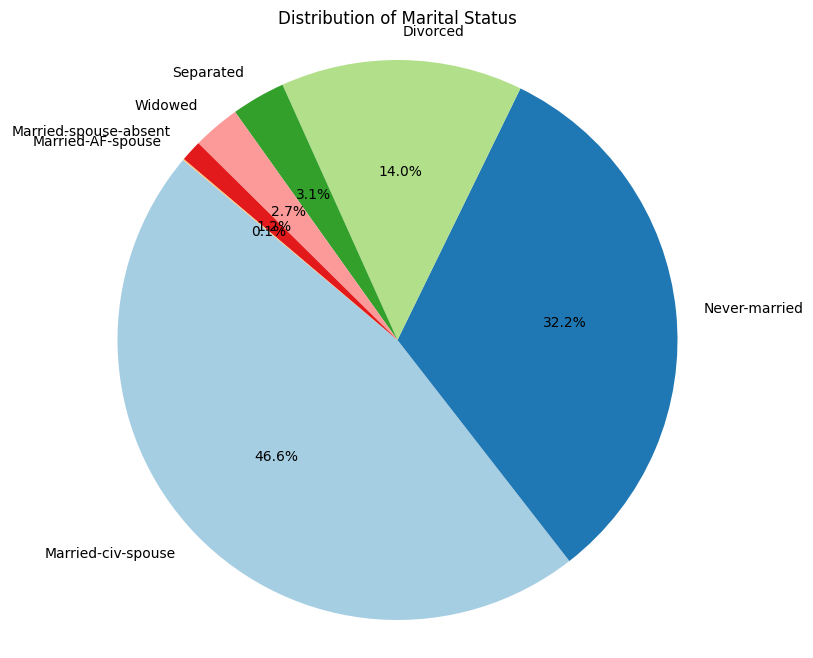

In [29]:
import matplotlib.pyplot as plt

marital_status_counts = df_cleaned['marital.status'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(marital_status_counts, labels=marital_status_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Marital Status')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Income distribution across 'education' levels

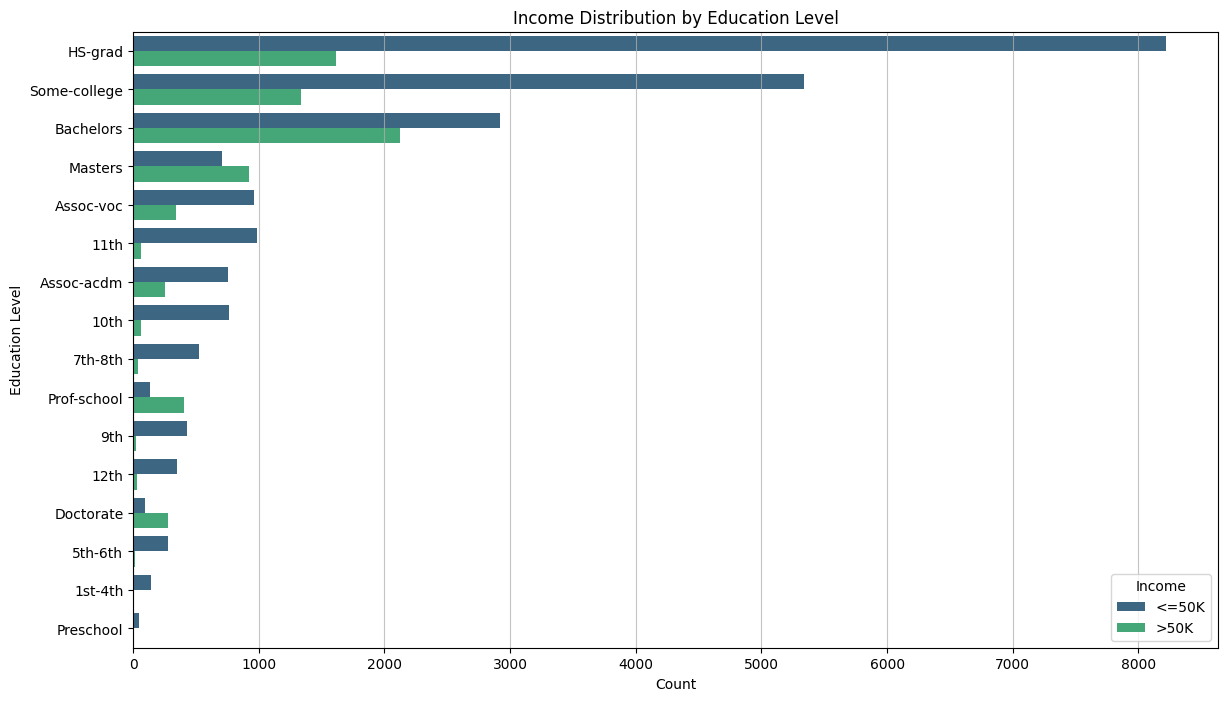

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.countplot(y='education', hue='income', data=df_cleaned, palette='viridis', order = df_cleaned['education'].value_counts().index)
plt.title('Income Distribution by Education Level')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.legend(title='Income')
plt.grid(axis='x', alpha=0.75)
plt.show()

### Income distribution across 'marital status'

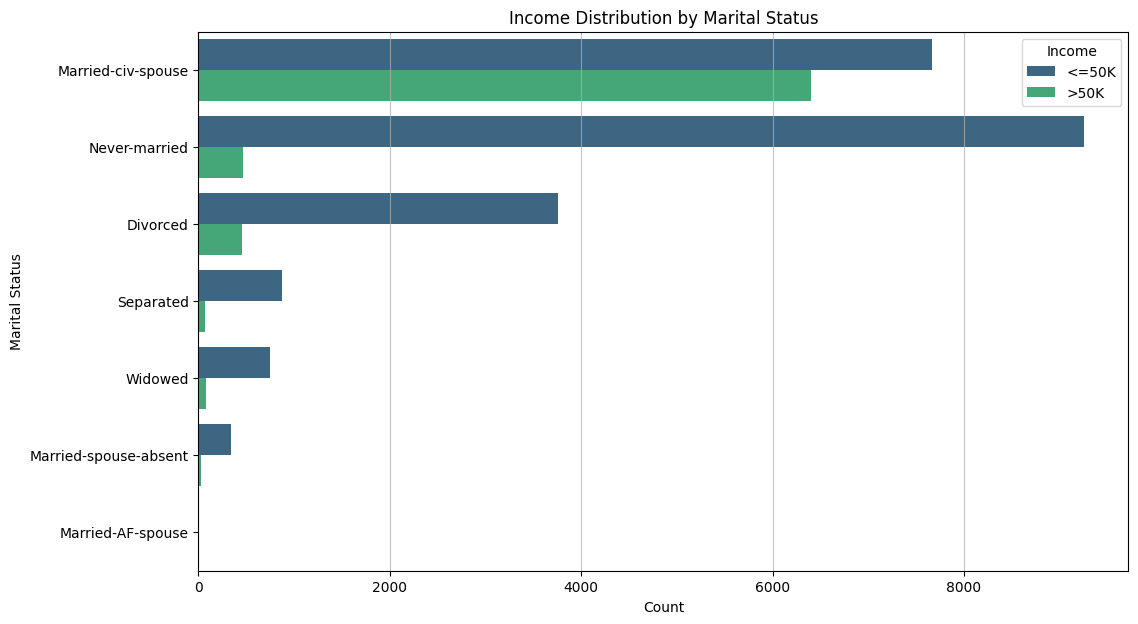

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(y='marital.status', hue='income', data=df_cleaned, palette='viridis', order = df_cleaned['marital.status'].value_counts().index)
plt.title('Income Distribution by Marital Status')
plt.xlabel('Count')
plt.ylabel('Marital Status')
plt.legend(title='Income')
plt.grid(axis='x', alpha=0.75)
plt.show()

### Income distribution across 'sex'

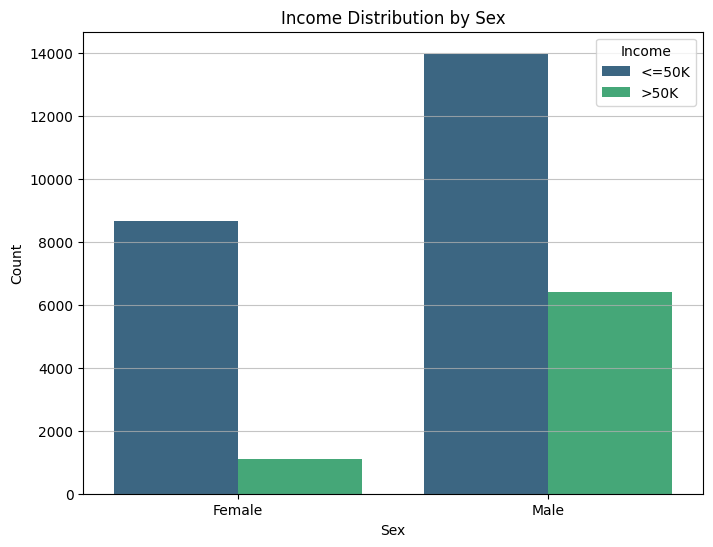

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='sex', hue='income', data=df_cleaned, palette='viridis')
plt.title('Income Distribution by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Income')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Income distribution across 'age'

For continuous variables like 'age', a `histplot` with `hue` is more appropriate to visualize the distribution of income across age ranges, rather than a `countplot` which would be too dense.

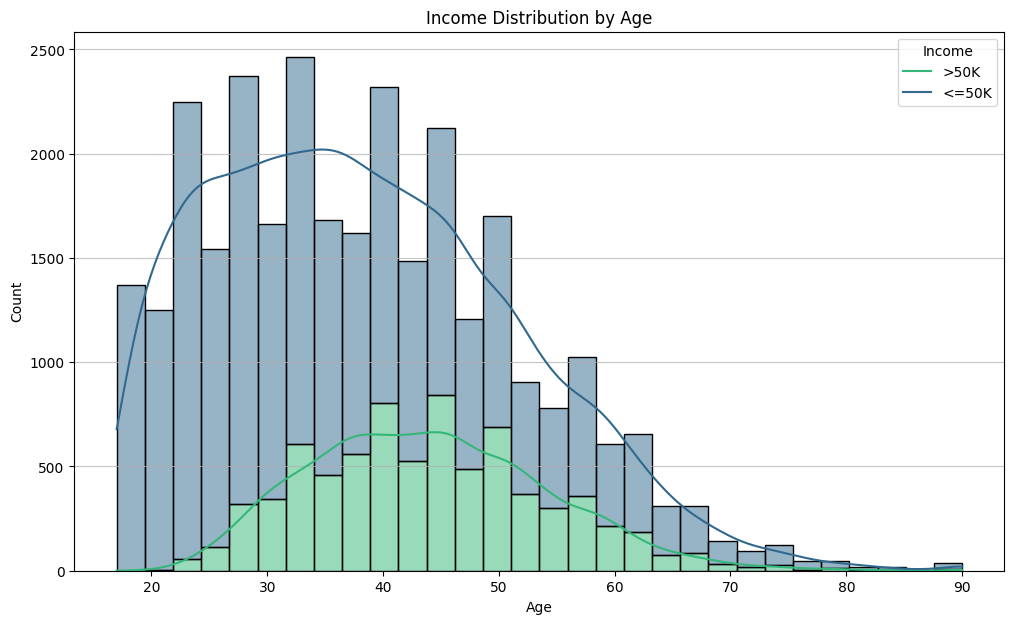

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.histplot(data=df_cleaned, x='age', hue='income', multiple='stack', bins=30, kde=True, palette='viridis')
plt.title('Income Distribution by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Income', labels=['>50K', '<=50K'])
plt.grid(axis='y', alpha=0.75)
plt.show()

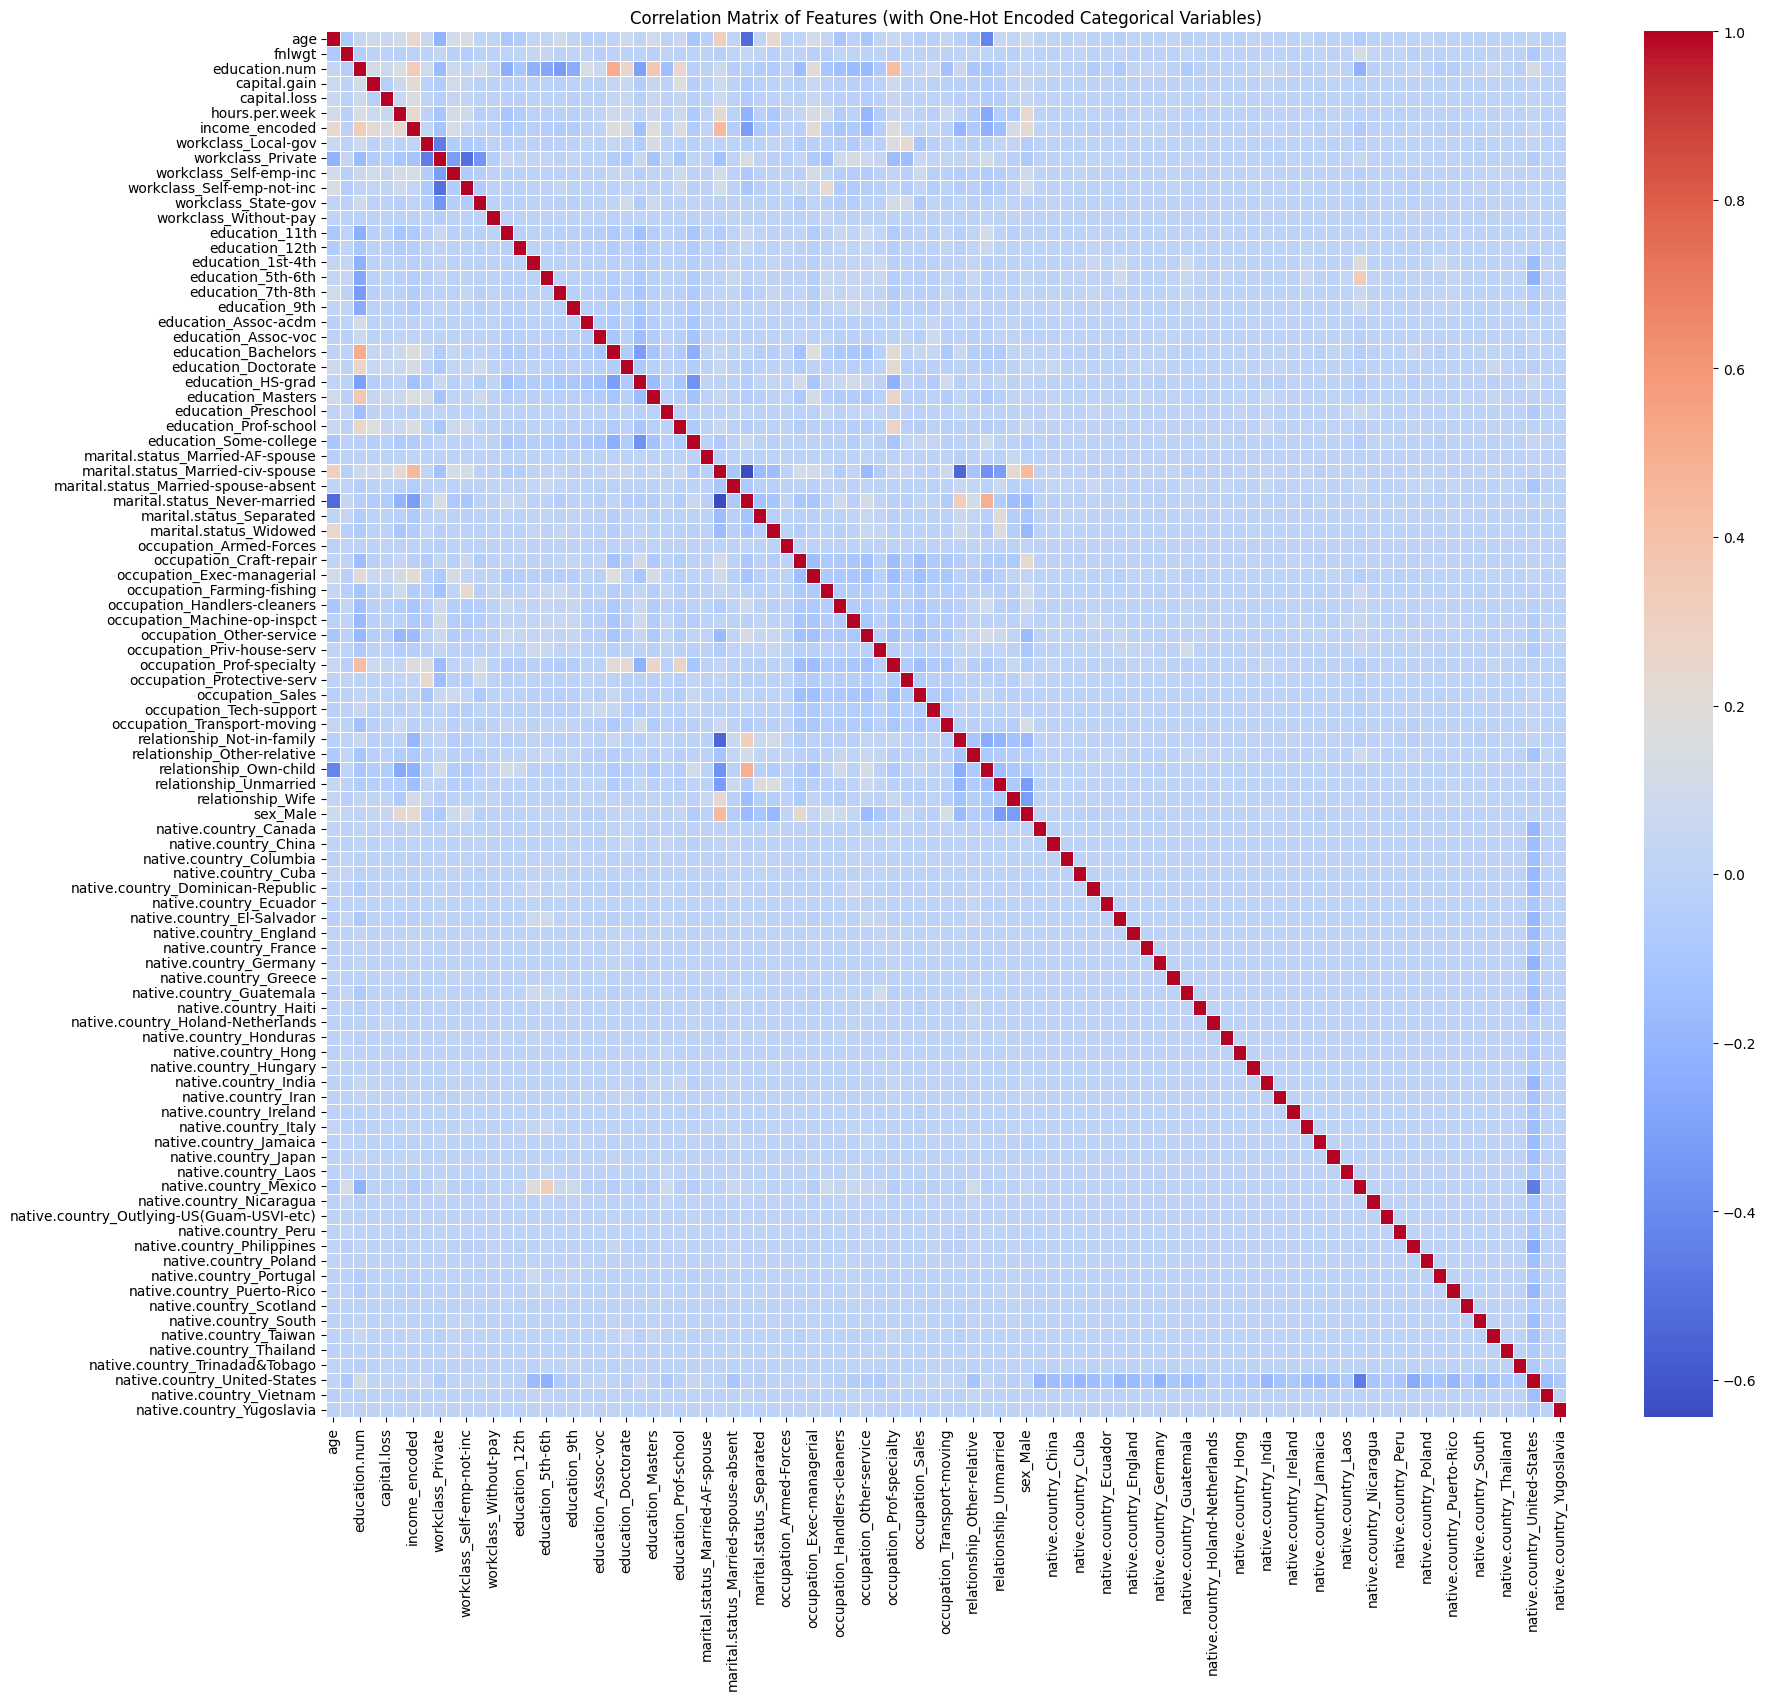


Top correlated features with income:


,income_encoded
income_encoded,1.000000
marital.status_Married-civ-spouse,0.445418
education.num,0.335286
age,0.241998
hours.per.week,0.229480
...,...
relationship_Unmarried,-0.145799
occupation_Other-service,-0.165934
relationship_Not-in-family,-0.193258
relationship_Own-child,-0.226186


In [34]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Make a copy to avoid modifying the original df_cleaned for this analysis
df_correlation = df_cleaned.copy()

# Convert 'income' to numerical using LabelEncoder
le = LabelEncoder()
df_correlation['income_encoded'] = le.fit_transform(df_correlation['income'])

# Identify categorical columns (excluding the original 'income' and numerical columns)
categorical_cols = df_correlation.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('income') # Remove original income column

# Apply one-hot encoding to other categorical columns
df_correlation = pd.get_dummies(df_correlation, columns=categorical_cols, drop_first=True)

# Drop the original 'income' column as we now have 'income_encoded'
df_correlation = df_correlation.drop('income', axis=1)

# Calculate the correlation matrix
correlation_matrix = df_correlation.corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features (with One-Hot Encoded Categorical Variables)')
plt.show()

# Find correlations with 'income_encoded'
income_correlations = correlation_matrix['income_encoded'].sort_values(ascending=False)

print("\nTop correlated features with income:")
display(income_correlations)

Sesssion 6

Label encode all the categorical columns

In [36]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_cleaned.copy()

# Identify categorical columns
categorical_cols = df_encoded.select_dtypes(include='object').columns

# Apply LabelEncoder to each categorical column
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le # Store the encoder for potential inverse transformation

print("DataFrame after Label Encoding categorical columns:")
display(df_encoded.head())
print("\nData types after encoding:")
display(df_encoded.info())

DataFrame after Label Encoding categorical columns:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,2,132870,11,9,6,3,1,0,0,4356,18,38,0
3,54,2,140359,5,4,0,6,4,0,0,3900,40,38,0
4,41,2,264663,15,10,5,9,3,0,0,3900,40,38,0
5,34,2,216864,11,9,0,7,4,0,0,3770,45,38,0
6,38,2,150601,0,6,5,0,4,1,0,3770,40,38,0



Data types after encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 1 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  int64
 2   fnlwgt          30162 non-null  int64
 3   education       30162 non-null  int64
 4   education.num   30162 non-null  int64
 5   marital.status  30162 non-null  int64
 6   occupation      30162 non-null  int64
 7   relationship    30162 non-null  int64
 8   sex             30162 non-null  int64
 9   capital.gain    30162 non-null  int64
 10  capital.loss    30162 non-null  int64
 11  hours.per.week  30162 non-null  int64
 12  native.country  30162 non-null  int64
 13  income          30162 non-null  int64
dtypes: int64(14)
memory usage: 3.5 MB


None

In [ ]:
# Define independent variables (X) and dependent variable (Y)
X = df_encoded.drop('income', axis=1)
Y = df_encoded['income']

print("Independent variables (X):")
display(X.head())
print("\nDependent variable (Y):")
display(Y.head())

In [37]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the independent variables (X)
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back to a DataFrame for easier inspection (optional but good practice)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Scaled Independent variables (X_scaled_df):")
display(X_scaled_df.head())

Scaled Independent variables (X_scaled_df):


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country
1,3.316630,-0.208955,-0.538790,0.174763,-0.439738,2.282969,-0.734545,-0.261249,-1.443405,-0.147445,10.555814,-1.914161,0.264924
3,1.184831,-0.208955,-0.467906,-1.399120,-2.400559,-1.722396,0.009964,1.612215,-1.443405,-0.147445,9.427915,-0.077734,0.264924
4,0.195067,-0.208955,0.708645,1.224018,-0.047574,1.615408,0.754473,0.987727,-1.443405,-0.147445,9.427915,-0.077734,0.264924
5,-0.337883,-0.208955,0.256222,0.174763,-0.439738,-1.722396,0.258134,1.612215,-1.443405,-0.147445,9.106365,0.339636,0.264924
6,-0.033340,-0.208955,-0.370964,-2.710688,-1.616231,1.615408,-1.479055,1.612215,0.692806,-0.147445,9.106365,-0.077734,0.264924


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original dataset shape: {Counter(Y)}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the scaled features and target variable
X_resampled, Y_resampled = smote.fit_resample(X_scaled, Y)

print(f"Resampled dataset shape: {Counter(Y_resampled)}")

# Convert resampled X back to DataFrame for consistency if needed, using original column names
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)

print("\nResampled Independent variables (X_resampled_df):")
display(X_resampled_df.head())
print("\nResampled Dependent variable (Y_resampled):")
display(Y_resampled.head())

In [ ]:
from sklearn.model_selection import train_test_split

# Perform train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of Y_train:", Y_train.shape)
print("Shape of Y_test:", Y_test.shape)

Perform Data Modelling
Train Logistic Regression Model, KNN Classifier Model, SVM Classifier, Naive Bayes
Classifier, Decision Tree Classifier and Random Forest Classifier

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Dictionary to store models and their performance
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42, probability=True),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    Y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    roc_auc = roc_auc_score(Y_test, Y_proba) if Y_proba is not None else 'N/A'
    cm = confusion_matrix(Y_test, Y_pred)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': cm.tolist()
    }

    print(f"{name} Performance:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}" if Y_proba is not None else f"  ROC-AUC: {roc_auc}")
    print(f"  Confusion Matrix:\n{cm}")

print("\n--- Summary of Model Performances ---")
for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  Precision: {metrics['Precision']:.4f}")
    print(f"  Recall: {metrics['Recall']:.4f}")
    print(f"  F1-Score: {metrics['F1-Score']:.4f}")
    print(f"  ROC-AUC: {metrics['ROC-AUC']:.4f}" if metrics['ROC-AUC'] != 'N/A' else f"  ROC-AUC: {metrics['ROC-AUC']}")


Training Logistic Regression...
Logistic Regression Performance:
  Accuracy: 0.7598
  Precision: 0.7591
  Recall: 0.7575
  F1-Score: 0.7583
  ROC-AUC: 0.8472
  Confusion Matrix:
[[3470 1084]
 [1093 3415]]

Training KNN...
KNN Performance:
  Accuracy: 0.8521
  Precision: 0.8063
  Recall: 0.9250
  F1-Score: 0.8616
  ROC-AUC: 0.9181
  Confusion Matrix:
[[3552 1002]
 [ 338 4170]]

Training SVM...
SVM Performance:
  Accuracy: 0.8346
  Precision: 0.7980
  Recall: 0.8937
  F1-Score: 0.8432
  ROC-AUC: 0.9139
  Confusion Matrix:
[[3534 1020]
 [ 479 4029]]

Training Naive Bayes...
Naive Bayes Performance:
  Accuracy: 0.6945
  Precision: 0.8631
  Recall: 0.4587
  F1-Score: 0.5991
  ROC-AUC: 0.8578
  Confusion Matrix:
[[4226  328]
 [2440 2068]]

Training Decision Tree...
Decision Tree Performance:
  Accuracy: 0.8518
  Precision: 0.8464
  Recall: 0.8578
  F1-Score: 0.8520
  ROC-AUC: 0.8520
  Confusion Matrix:
[[3852  702]
 [ 641 3867]]

Training Random Forest...
Random Forest Performance:
  Accura

In [39]:
import pandas as pd

# Find the best model based on Accuracy
best_accuracy_model = max(results.items(), key=lambda item: item[1]['Accuracy'])

# Find the best model based on F1-Score
best_f1_model = max(results.items(), key=lambda item: item[1]['F1-Score'])

print(f"\nBest model by Accuracy: {best_accuracy_model[0]} with Accuracy: {best_accuracy_model[1]['Accuracy']:.4f}")
print(f"Best model by F1-Score: {best_f1_model[0]} with F1-Score: {best_f1_model[1]['F1-Score']:.4f}")

# Display all results in a DataFrame for better comparison
results_df = pd.DataFrame.from_dict(results, orient='index')
# Exclude 'Confusion Matrix' for a cleaner summary display
results_df_summary = results_df.drop(columns=['Confusion Matrix'])
display(results_df_summary.sort_values(by=['Accuracy', 'F1-Score'], ascending=False))


Best model by Accuracy: Random Forest with Accuracy: 0.8995
Best model by F1-Score: Random Forest with F1-Score: 0.9005


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.899470,0.887024,0.914374,0.900492,0.963324
KNN,0.852130,0.806265,0.925022,0.861570,0.918100
Decision Tree,0.851799,0.846356,0.857808,0.852044,0.852017
SVM,0.834584,0.797980,0.893744,0.843152,0.913862
Logistic Regression,0.759766,0.759058,0.757542,0.758299,0.847179
Naive Bayes,0.694549,0.863105,0.458740,0.599073,0.857817
